## Loading & Pre-Processing Data

#### 1. Importing the Images

The first dataset, from Kaggle, consists of about 8,000 samples of solar flares

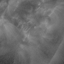

In [2]:
import os
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt

IMG = 64

def load_gray(path):
    img = Image.open(path).resize((IMG, IMG))
    return img

img1 = load_gray('data\\training\\11388\\2012_01_07_02_27_01_0\\2012-01-06T142701__94.jpg')
display(img1)

### Loading a Set of Images
This function loads a set of images from the dataset. Giving it a sample number will return the target (peak emission) and the relevant images. If images are missing, they will be null with a flag.

In [3]:
import os
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

IMG = 24

# ----------------------------------------------------------------------
# STEP 3 — Turn each single image into many via data augmentation
# ----------------------------------------------------------------------
def augment(pil_img):
    """Return one randomly transformed 28x28 array in [0, 1]."""
    angle = np.random.uniform(-25, 25)                 # random rotation
    im = pil_img.rotate(angle, resample=Image.BILINEAR, fillcolor=0)
    # random shift
    dx, dy = np.random.randint(-3, 4), np.random.randint(-3, 4)
    im = im.transform((IMG, IMG), Image.AFFINE, (1, 0, dx, 0, 1, dy), fillcolor=0)
    arr = np.array(im, dtype=np.float32) / 255.0
    arr += np.random.normal(0, 0.06, arr.shape)        # random noise
    return np.clip(arr, 0, 1)

def build(pil_img, label, n):
    X = np.array([augment(pil_img) for _ in range(n)], dtype=np.float32)
    y = np.full((n, 1), label, dtype=np.float32)
    return X, y



def load_gray(path):
    img = Image.open(path).resize((IMG, IMG))
    return img

def find_folder(root_dir, folder_name):
    for root, dirs, files in os.walk(root_dir):
        if folder_name in dirs:
            return os.path.join(root, folder_name)
    
    return None

    
# Either 94, 131, 171, 193, 211, 304, 335, 1700, continuum, or magnetogram
SOURCE_TYPE = "magnetogram"

# Threshold of what the model considers a solar flare.
# C-Class (10e-6 - 10e-5): Limited effects on Earth
# M-Class (10e-5 - 10e-4): Can cause radio blackouts near poles
# X-Class (>10e-4): Can cause large radio blackouts & big problems

FLARE_THRESHOLD = 1e-5


def load_image_set(sample_id):

    # Get the data directory
    data_dir = find_folder("data", str(sample_id))

    # Get all the relevant files
    relevant_files = []
    for root, dirs, files in os.walk(data_dir):
        relevant_files = [os.path.join(root, f) for f in files if SOURCE_TYPE in f]

    # Load all relevant images
    X_list = []
    y_list = []

    # Determine whether this was a solar flare
    metadata = pd.read_csv(
        os.path.join(os.path.dirname(data_dir), "meta_data.csv")
    )    

    flux = 0
    for index, row in metadata.iterrows():
        if str(sample_id) in row["id"]:
            flux = row["peak_flux"]
            break
            

    # Go through and process all the images
    for file in relevant_files:
        curr_img = load_gray(file)
        display(curr_img)
        curr_X, curr_y = build(curr_img, flux > FLARE_THRESHOLD, 200)
        X_list.append(curr_X)
        y_list.append(curr_y)

    return X_list, y_list

# Use this to get the most relevant image
X_list, y_list = load_image_set(12106)
X_augmented = X_list[0][3]
y = y_list[3]


Using device: cuda
Found 1091 sample folders
Building train split...
  processed 20/763
  processed 40/763
  processed 60/763
  processed 80/763
  processed 100/763
  processed 120/763
  processed 140/763
  processed 160/763
  processed 180/763
  processed 200/763
  processed 220/763
  processed 240/763
  processed 260/763
  processed 280/763
  processed 300/763
  processed 320/763
  processed 340/763
  processed 360/763
  processed 380/763
  processed 400/763
  processed 420/763
  processed 440/763
  processed 460/763
  processed 480/763
  processed 500/763
  processed 520/763
  processed 540/763
  processed 560/763
  processed 580/763
  processed 600/763
  processed 620/763
  processed 640/763
  processed 660/763
  processed 680/763
  processed 700/763
  processed 720/763
  processed 740/763
  processed 760/763
Building val split...
  processed 20/164
  processed 40/164
  processed 60/164
  processed 80/164
  processed 100/164
  processed 120/164
  processed 140/164
  processed 160/1

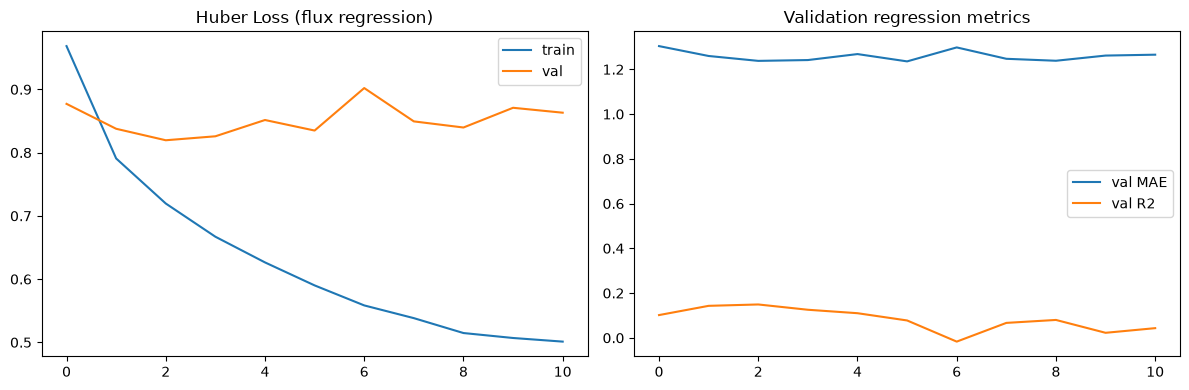

Saved model to flare_regression_cnn.pt


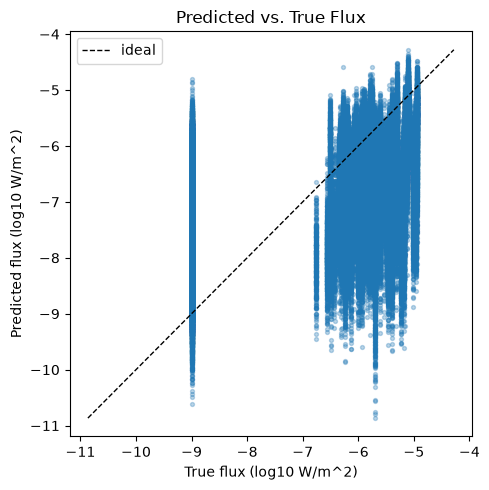

Saved test set predictions to test_flux_predictions.csv


In [19]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMG = 24
SOURCE_TYPE = "magnetogram"

# ----------------------------------------------------------------------
# Reuse your existing helpers
# ----------------------------------------------------------------------
def load_gray(path):
    img = Image.open(path).resize((IMG, IMG)).convert("L")
    return img

def find_folder(root_dir, folder_name):
    for root, dirs, files in os.walk(root_dir):
        if folder_name in dirs:
            return os.path.join(root, folder_name)
    return None

def augment(pil_img):
    angle = np.random.uniform(-25, 25)
    im = pil_img.rotate(angle, resample=Image.BILINEAR, fillcolor=0)
    dx, dy = np.random.randint(-3, 4), np.random.randint(-3, 4)
    im = im.transform((IMG, IMG), Image.AFFINE, (1, 0, dx, 0, 1, dy), fillcolor=0)
    arr = np.array(im, dtype=np.float32) / 255.0
    arr += np.random.normal(0, 0.06, arr.shape)
    return np.clip(arr, 0, 1)

def build(pil_img, value, n):
    """value is the continuous regression target: log10(peak_flux)."""
    X = np.array([augment(pil_img) for _ in range(n)], dtype=np.float32)
    y = np.full((n, 1), value, dtype=np.float32)
    return X, y

def load_image_set(sample_id, n_augment=50):
    data_dir = find_folder("data/training", str(sample_id))
    if data_dir is None:
        return [], []

    relevant_files = []
    for root, dirs, files in os.walk(data_dir):
        relevant_files += [os.path.join(root, f) for f in files if SOURCE_TYPE in f]

    metadata_path = os.path.join(os.path.dirname(data_dir), "meta_data.csv")
    if not os.path.exists(metadata_path):
        return [], []
    metadata = pd.read_csv(metadata_path)

    flux = -8.0  # floor value (~A-class) used if no matching row is found
    for _, row in metadata.iterrows():
        if str(sample_id) in str(row["id"]):
            # log10, with a small floor to avoid log10(0) = -inf for any
            # zero/negative flux entries in the metadata. This is the
            # regression target we train against.
            flux = np.log10(max(row["peak_flux"], 1e-9))
            break

    X_list, y_list = [], []
    for file in relevant_files:
        curr_img = load_gray(file)
        curr_X, curr_y = build(curr_img, flux, n_augment)
        X_list.append(curr_X)
        y_list.append(curr_y)

    return X_list, y_list

# ----------------------------------------------------------------------
# Build the FULL dataset across every sample folder, grouped by sample_id
# to avoid leakage between train/val/test splits
# ----------------------------------------------------------------------
TRAIN_ROOT = "data/training"

sample_ids = [d for d in os.listdir(TRAIN_ROOT)
              if os.path.isdir(os.path.join(TRAIN_ROOT, d))]
print(f"Found {len(sample_ids)} sample folders")

# Split by sample_id FIRST, then augment within each split
train_ids, temp_ids = train_test_split(sample_ids, test_size=0.3, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)

def build_split(ids, n_augment):
    Xs, ys = [], []
    for i, sample_id in enumerate(ids):
        X_list, y_list = load_image_set(sample_id, n_augment=n_augment)
        for X, y in zip(X_list, y_list):
            Xs.append(X)
            ys.append(y)
        if (i + 1) % 20 == 0:
            print(f"  processed {i + 1}/{len(ids)}")
    if not Xs:
        return np.empty((0, IMG, IMG)), np.empty((0,))
    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0).ravel()
    return X, y

print("Building train split...")
X_train, y_train = build_split(train_ids, n_augment=50)
print("Building val split...")
X_val, y_val = build_split(val_ids, n_augment=20)
print("Building test split...")
X_test, y_test = build_split(test_ids, n_augment=20)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Flux (log10) range — train:", y_train.min(), "to", y_train.max())
print("Flux (log10) range — val:  ", y_val.min(), "to", y_val.max())
print("Flux (log10) range — test: ", y_test.min(), "to", y_test.max())

# ----------------------------------------------------------------------
# Dataset / DataLoader
# ----------------------------------------------------------------------
class FlareDataset(Dataset):
    def __init__(self, X, y):
        # (N, H, W) -> (N, 1, H, W)
        self.X = torch.from_numpy(X).float().unsqueeze(1)
        self.y = torch.from_numpy(y).float().unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = FlareDataset(X_train, y_train)
val_ds = FlareDataset(X_val, y_val)
test_ds = FlareDataset(X_test, y_test)

BATCH_SIZE = 512
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ----------------------------------------------------------------------
# CNN model — regressor that predicts log10(flux) directly
# ----------------------------------------------------------------------
class FlareRegressionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(64, 64)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # raw predicted log10(flux) — no activation
        return x

model = FlareRegressionCNN().to(device)
print(model)

# ----------------------------------------------------------------------
# Loss, optimizer — Huber loss is more robust than MSE to the heavy tail
# of rare, very high-flux (X-class) events in the flux distribution.
# ----------------------------------------------------------------------
criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=4
)

# ----------------------------------------------------------------------
# Evaluation: pure regression metrics only
# ----------------------------------------------------------------------
from sklearn.metrics import mean_absolute_error, r2_score

def evaluate(loader):
    model.eval()
    all_preds, all_targets = [], []
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            total_loss += loss.item() * xb.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(yb.cpu())
    all_preds = torch.cat(all_preds).numpy().ravel()
    all_targets = torch.cat(all_targets).numpy().ravel()

    loss_val = total_loss / len(loader.dataset)
    mae = mean_absolute_error(all_targets, all_preds)
    try:
        r2 = r2_score(all_targets, all_preds)
    except ValueError:
        r2 = float("nan")

    return loss_val, mae, r2

# ----------------------------------------------------------------------
# Training loop with early stopping on val loss
# ----------------------------------------------------------------------
EPOCHS = 50
PATIENCE = 8

best_val_loss = np.inf
best_state = None
epochs_no_improve = 0

history = {"train_loss": [], "val_loss": [], "val_mae": [], "val_r2": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_mae, val_r2 = evaluate(val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)
    history["val_r2"].append(val_r2)

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | train_loss {train_loss:.4f} | "
          f"val_loss {val_loss:.4f} | val_mae {val_mae:.4f} | val_r2 {val_r2:.3f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Restore best weights
if best_state is not None:
    model.load_state_dict(best_state)

# ----------------------------------------------------------------------
# Test evaluation
# ----------------------------------------------------------------------
test_loss, test_mae, test_r2 = evaluate(test_loader)
print(f"Test loss: {test_loss:.4f} | Test MAE: {test_mae:.4f} | Test R2: {test_r2:.3f}")

# ----------------------------------------------------------------------
# Plot training curves
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Huber Loss (flux regression)")
axes[0].legend()

axes[1].plot(history["val_mae"], label="val MAE")
axes[1].plot(history["val_r2"], label="val R2")
axes[1].set_title("Validation regression metrics")
axes[1].legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# Save model
# ----------------------------------------------------------------------
torch.save(model.state_dict(), "flare_regression_cnn.pt")
print("Saved model to flare_regression_cnn.pt")

# ----------------------------------------------------------------------
# Scatter plot: predicted vs. true flux
# ----------------------------------------------------------------------
def get_predictions(loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds = model(xb).cpu().numpy().ravel()
            all_preds.append(preds)
            all_targets.append(yb.numpy().ravel())
    return np.concatenate(all_preds), np.concatenate(all_targets)

test_pred_flux, test_true_flux = get_predictions(test_loader)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(test_true_flux, test_pred_flux, alpha=0.3, s=8)
lims = [min(test_true_flux.min(), test_pred_flux.min()),
        max(test_true_flux.max(), test_pred_flux.max())]
ax.plot(lims, lims, "k--", linewidth=1, label="ideal")
ax.set_xlabel("True flux (log10 W/m^2)")
ax.set_ylabel("Predicted flux (log10 W/m^2)")
ax.set_title("Predicted vs. True Flux")
ax.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# Save raw predictions to disk (true flux, predicted flux) so you can
# apply whatever flare threshold/logic you want afterward.
# ----------------------------------------------------------------------
pred_df = pd.DataFrame({
    "true_log10_flux": test_true_flux,
    "pred_log10_flux": test_pred_flux,
})
pred_df.to_csv("test_flux_predictions.csv", index=False)
print("Saved test set predictions to test_flux_predictions.csv")


True flux:
[1.e-09 1.e-09 1.e-09 ... 1.e-09 1.e-09 1.e-09]

Predicted flux:
[1.0187690e-07 3.2096193e-07 1.2493921e-07 ... 6.8873746e-08 7.0045893e-08
 6.6051022e-08]

Confusion matrix (derived from predicted flux):
[[91032   628]
 [ 3418   222]]

Classification report (derived from predicted flux):
              precision    recall  f1-score   support

    No Flare       0.96      0.99      0.98     91660
       Flare       0.26      0.06      0.10      3640

    accuracy                           0.96     95300
   macro avg       0.61      0.53      0.54     95300
weighted avg       0.94      0.96      0.94     95300



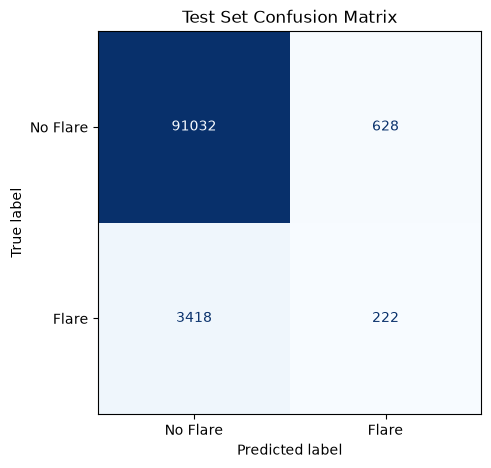

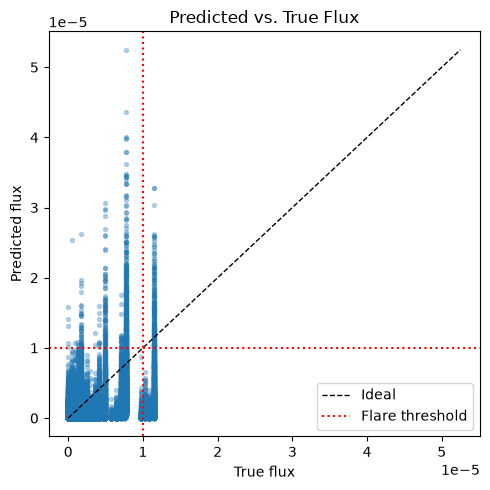

In [20]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------------
# Convert log10 flux back to normal flux
# ----------------------------------------------------------------------
test_pred = 10 ** test_pred_flux
test_true = 10 ** test_true_flux

# ----------------------------------------------------------------------
# Convert flux values to flare / no-flare labels
# ----------------------------------------------------------------------
test_pred_flare = (test_pred > FLARE_THRESHOLD).astype(int)
test_true_flare = (test_true > FLARE_THRESHOLD).astype(int)

# ----------------------------------------------------------------------
# Confusion matrix
# ----------------------------------------------------------------------
cm = confusion_matrix(
    test_true_flare,
    test_pred_flare,
    labels=[0, 1]
)

print("True flux:")
print(test_true)

print("\nPredicted flux:")
print(test_pred)

print("\nConfusion matrix (derived from predicted flux):")
print(cm)

print("\nClassification report (derived from predicted flux):")
print(
    classification_report(
        test_true_flare,
        test_pred_flare,
        labels=[0, 1],
        target_names=["No Flare", "Flare"],
        zero_division=0
    )
)

# ----------------------------------------------------------------------
# Confusion matrix plot
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Flare", "Flare"]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

ax.set_title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# Scatter plot: predicted vs. true flux
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(
    test_true,
    test_pred,
    alpha=0.3,
    s=8
)

# Determine plot limits
lims = [
    min(test_true.min(), test_pred.min()),
    max(test_true.max(), test_pred.max())
]

# Ideal prediction line
ax.plot(
    lims,
    lims,
    "k--",
    linewidth=1,
    label="Ideal"
)

# Flare threshold
ax.axhline(
    FLARE_THRESHOLD,
    color="r",
    linestyle=":",
    label="Flare threshold"
)

ax.axvline(
    FLARE_THRESHOLD,
    color="r",
    linestyle=":"
)

ax.set_xlabel("True flux")
ax.set_ylabel("Predicted flux")
ax.set_title("Predicted vs. True Flux")
ax.legend()

plt.tight_layout()
plt.show()